In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

# Results:

## JAKOBS:

### Average stats:

In [100]:
def get_population_stats(dataset, n_pop):
    best_result_avgs = []
    avg_times = []
    evaluations_per_seconds = []
    
    for i in range(1, 6):
        data_path = f"complete/rts/{dataset}/{n_pop}/aggregated_{i}_1_1_{n_pop}.csv"
        log = pd.read_csv(data_path)

        best_result_avgs.append(log.iloc[-1]['max'])
        avg_times.append(log['time_gen'].sum())
        evaluations_per_seconds.append((n_pop * 100) / log['time_gen'].sum())

    best_result_avg = np.mean(np.array(best_result_avgs))
    avg_time = np.mean(np.array(avg_times))
    evaluations_per_second = np.mean(np.array(evaluations_per_seconds))

    return best_result_avg, avg_time, evaluations_per_second

In [101]:
def get_general_stats(dataset):
    n_pops = [10, 20, 30]
    data = {
        "Population size": [],
        "Best results' average": [],
        "Average time": [],
        "Evaluations per second": []
    }

    for n_pop in n_pops:
        best_result_avg, avg_time, evaluations_per_second = get_population_stats(dataset, n_pop)
        data["Population size"].append(n_pop)
        data["Best results' average"].append(best_result_avg)
        data["Average time"].append(avg_time)
        data["Evaluations per second"].append(evaluations_per_second)

    return pd.DataFrame(data)
        

In [102]:
get_general_stats("JAKOBS")

,Population size,Best results' average,Average time,Evaluations per second
0,10,0.741714,13.387282,118.072095
1,20,0.745024,26.801184,116.355831
2,30,0.754119,40.114371,117.708956


### Mean Convergence of Peak Performance:

In [107]:
def plot_peak_performance(dataset, n_pop):
    max_fitnesses = []

    # Calculate the mean peak performance
    for i in range(1, 6):
        data_path = f"complete/rts/{dataset}/{n_pop}/aggregated_{i}_1_1_{n_pop}.csv"
        log = pd.read_csv(data_path)

        max_fitnesses.append(log["max"].to_numpy())

    max_fitnesses = np.mean(np.array(max_fitnesses), axis=0)

    # Number of generations' vector
    generations = np.arange(len(max_fitnesses))

    # Build the graphic
    plt.plot(generations, max_fitnesses)

    # Plot the labels
    plt.title(f"Mean Convergence of Peak Performance across {dataset} Instances (population size: {n_pop})")
    plt.xlabel("Generation")
    plt.ylabel("Maximum Fitness")

    # Limits' adjusments
    plt.xlim(0, len(generations) - 1)
    plt.ylim(np.min(max_fitnesses) - 0.01, np.max(max_fitnesses + 0.01))

Population size: 10

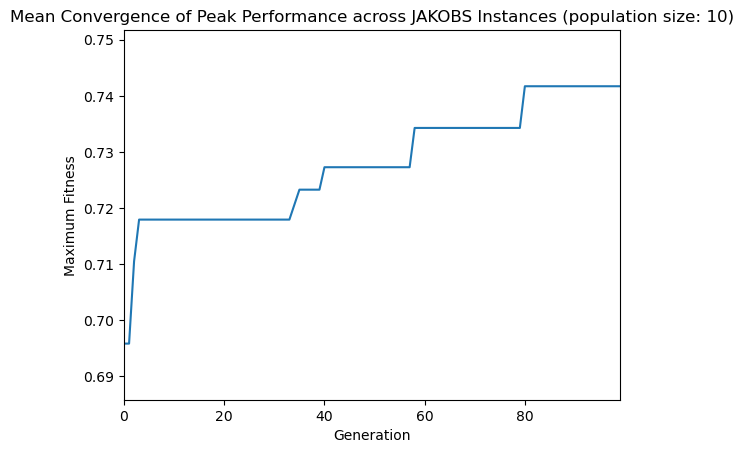

In [112]:
plot_peak_performance("JAKOBS", 10)

Population size: 20

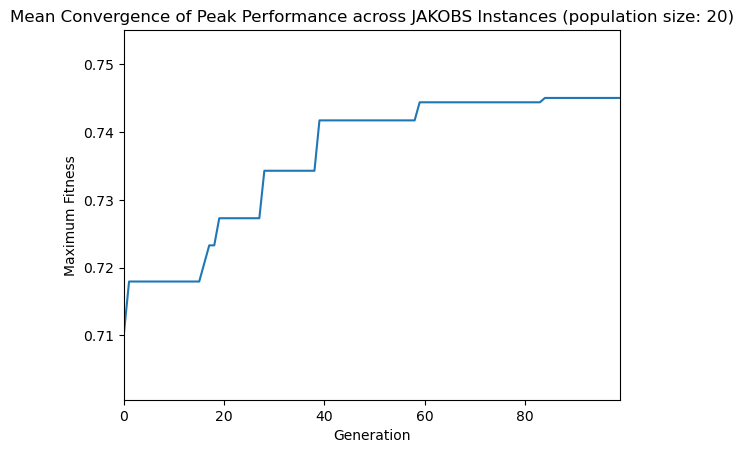

In [109]:
plot_peak_performance("JAKOBS", 20)

Population size: 30

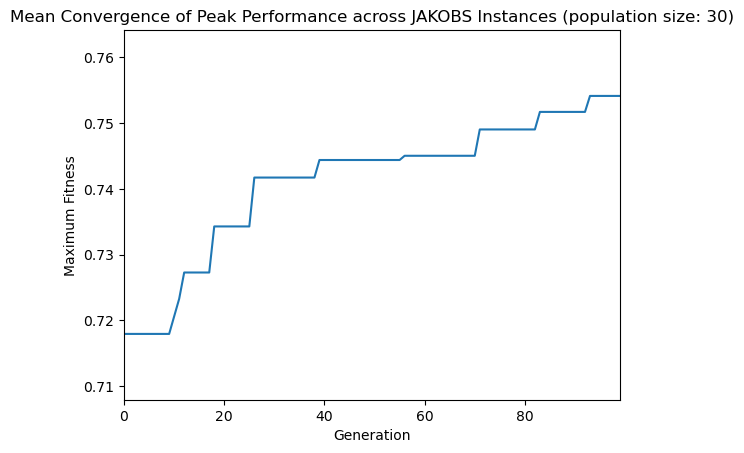

In [110]:
plot_peak_performance("JAKOBS", 30)

## HOPPER:

### Average stats:

In [111]:
get_general_stats("JAKOBS")

,Population size,Best results' average,Average time,Evaluations per second
0,10,0.741714,13.387282,118.072095
1,20,0.745024,26.801184,116.355831
2,30,0.754119,40.114371,117.708956


### Mean Convergence of Peak Performance:

Population size: 10

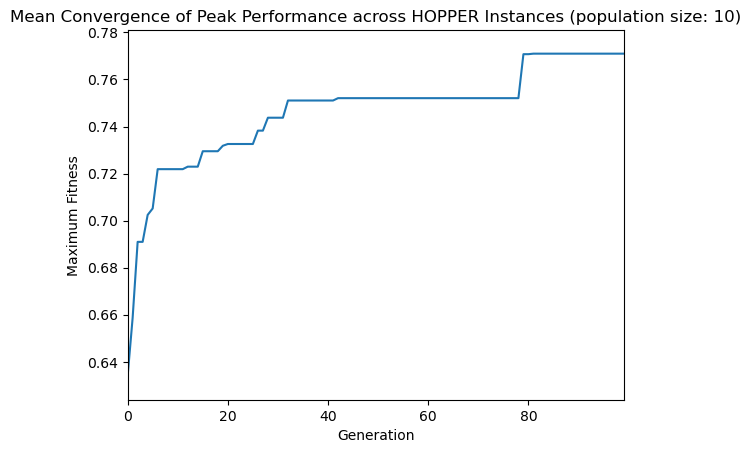

In [113]:
plot_peak_performance("HOPPER", 10)

Population size: 20

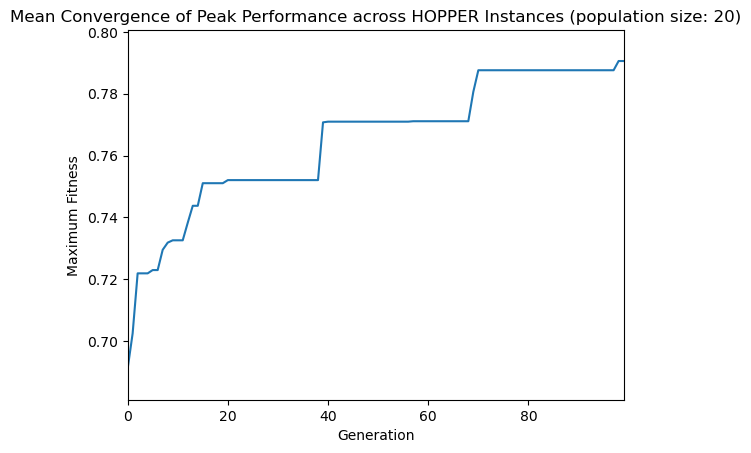

In [114]:
plot_peak_performance("HOPPER", 20)

Population size: 30

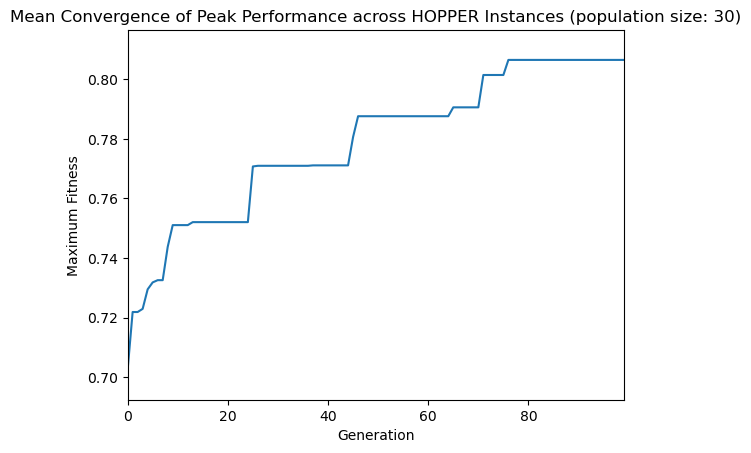

In [115]:
plot_peak_performance("HOPPER", 30)